# Práctica 1 - Ejercicio 1

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

En esta práctica se tienen que realizar dos ejercicios en dos cuadernos de Jupyter separados. Este es el primer ejercicio y el segundo se proporcionará durante la siguiente sesión de prácticas.

El primer ejercicio tiene como objetivo entrenar un modelo neuronal de capas lineales con PyTorch que ajuste simultáneamente las funciones siguientes:

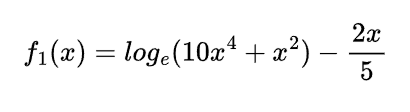

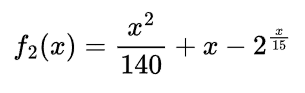

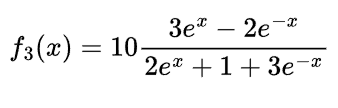

El modelo debe tener una entrada (x), tres salidas (f<sub>1</sub>(x), f<sub>2</sub>(x) y f<sub>3</sub>(x)) y debe ser capaz de generalizar en el rango x∈[-120,120]. Los datos para el entrenamiento se deben generar usando PyTorch con un error de media 0 y desviación típica 5 siguiendo una estrategia similar a la vista en clase. Para gestion de los datos durante el entrenamiento es requisito obligatorio usar *DataLoaders*.

Como resultado se espera este mismo cuaderno editado que incluya el código y los experimentos más relevantes realizados para alcanzar la mejor solución encontrada. Como resultado de esos experimentos, siguiendo lo visto en clase, se espera la visualización de las funciones aprendidas por el modelo y un breve análisis.

En los experimentos es obligatorio usar, además del subconjunto de entrenamiento, un subconjunto de validación durante el entrenamiento y un subconjunto de test que se usará solo después del entrenamiento para obtener una medida de error final. Esa medida del error final se debe realizar usando la media del error absoluto. Tanto el subconjunto de validación como el subconjunto de test deben contar con 500 ejemplos. El tamaño del conjunto de entrenamiento queda a criterio del estudiante.

El cuaderno entregado debe llamarse ApellidosNombrePractica1Ejercicio1.ipynb


In [16]:
# Importing the necessary libraries.
import torch
print(torch.cuda.is_available())

from torch.utils.data import TensorDataset, DataLoader, random_split

import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from tqdm import tqdm

import matplotlib.pyplot as plt

True


In [17]:
# Generating 5000 points between -120 and 120. float64 is used to avoid overflow in the calculations.
x = torch.linspace(-120, 120, steps = 5000, dtype = torch.float64)

# Applying each function.
y_first = torch.log(10 * x**4 + x**2 + 1e-7) - (2 * x / 5)
y_second = (x**2 / 140) + x - 2**(x/15)
y_third = 10 * ((3 * torch.exp(x) - 2 * torch.exp(-x)) / (2 * torch.exp(x) + 1 + 3 * torch.exp(-x)))

# Agruping three functions.
y = torch.stack((y_first, y_second, y_third), dim = 1)

# Converting data to float32 because PyTorch expects the input to be in this format.
x = x.to(torch.float32)
y = y.to(torch.float32)

# Generating noise.
noise = torch.normal(mean = 0, std = 5, size = y.shape)

# Adding noises to the data.
y_noisy = y + noise

# Converting data to form [N, 1] because PyTorch expects the input to be in this shape.
x_input = x.unsqueeze(1)

# Creating the dataset. Normalizing the input data by dividing it by 120.0 to keep the values between -1 and 1.
dataset = TensorDataset(x_input / 120.0, y_noisy)

# Dividing datasets into training (4000), validation sets (500) and testing sets (500).
train_ds, val_ds, test_ds = random_split(dataset, [4000, 500, 500])

# Creating dataloaders.
train_loader = DataLoader(train_ds, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_ds, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_ds, batch_size = 64, shuffle = False)

In [18]:
# Defining the neural network model.
class NeuralNetwork(nn.Module):
    def __init__(self):
        # Initializing the neural network.
        super(NeuralNetwork, self).__init__()

        # Defining the layers of the neural network.
        self.input = nn.Linear(1, 128)
        self.hidden1 = nn.Linear(128, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 3)

    def forward(self, x):
        # Defining the forward pass of the neural network.
        x = F.leaky_relu(self.input(x))
        x = F.leaky_relu(self.hidden1(x))
        x = F.leaky_relu(self.hidden2(x))

        # Applying the output layer.
        x = self.output(x)

        return x

model = NeuralNetwork()
print (model)

NeuralNetwork(
  (input): Linear(in_features=1, out_features=128, bias=True)
  (hidden1): Linear(in_features=128, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=3, bias=True)
)


In [19]:
# Defining the loss function and the optimizer.
epochs = 5000
learning_rate = 1e-3

# Defining the loss function.
loss_fn = nn.L1Loss()

# Defining the optimizer.
optimizer = optim.SGD(model.parameters(), lr = learning_rate)

# Defining the training and validation history lists.
train_history = []
val_history = []

# Defining the progress bar for the training loop.
epochs_loop = tqdm(range(epochs), desc = 'Training Progress', unit = 'epoch')

# Training the model.
for epoch in epochs_loop:
    # Training phase.
    model.train()
    loss_train_total = 0

    # Iterating over the training data.
    for x_batch, y_batch in train_loader:
        # Zeroing the gradients.
        optimizer.zero_grad()

        # Forward pass (x_batch is the input data and y_batch is the target data).
        predictions = model(x_batch)

        # Calculating the loss.
        loss = loss_fn(predictions, y_batch)

        # Backward pass. Calculating the gradients of the loss with respect to the model parameters.
        loss.backward()

        # Updating the model parameters (weights).
        optimizer.step()

        # Accumulating the training loss.
        loss_train_total += loss.item()

    # Calculating the average training loss for the epoch.
    media_train_loss = loss_train_total / len(train_loader)
    train_history.append(media_train_loss)

    # Validation phase.
    loss_val_total = 0

    # Iterating over the validation data.
    with torch.no_grad(): # Disabling gradient calculation for validation for efficiency.
        for x_val, y_val in val_loader:
            # Setting the model to evaluation mode.
            pred_val = model(x_val)

            # Calculating the validation loss.
            loss_val = loss_fn(pred_val, y_val)

            # Accumulating the validation loss.
            loss_val_total += loss_val.item()

    # Calculating the average validation loss for the epoch.
    media_val_loss = loss_val_total / len(val_loader)

    # Appending the average validation loss to the validation history list.
    val_history.append(media_val_loss)

    # Updating the progress bar with the current epoch's training and validation loss.
    epochs_loop.set_postfix({'Train Loss': media_train_loss, 'Val Loss': media_val_loss})

Training Progress: 100%|██████████| 5000/5000 [09:42<00:00,  8.58epoch/s, Train Loss=4.03, Val Loss=3.97]


Error final (MAE) on the test set: 4.1070


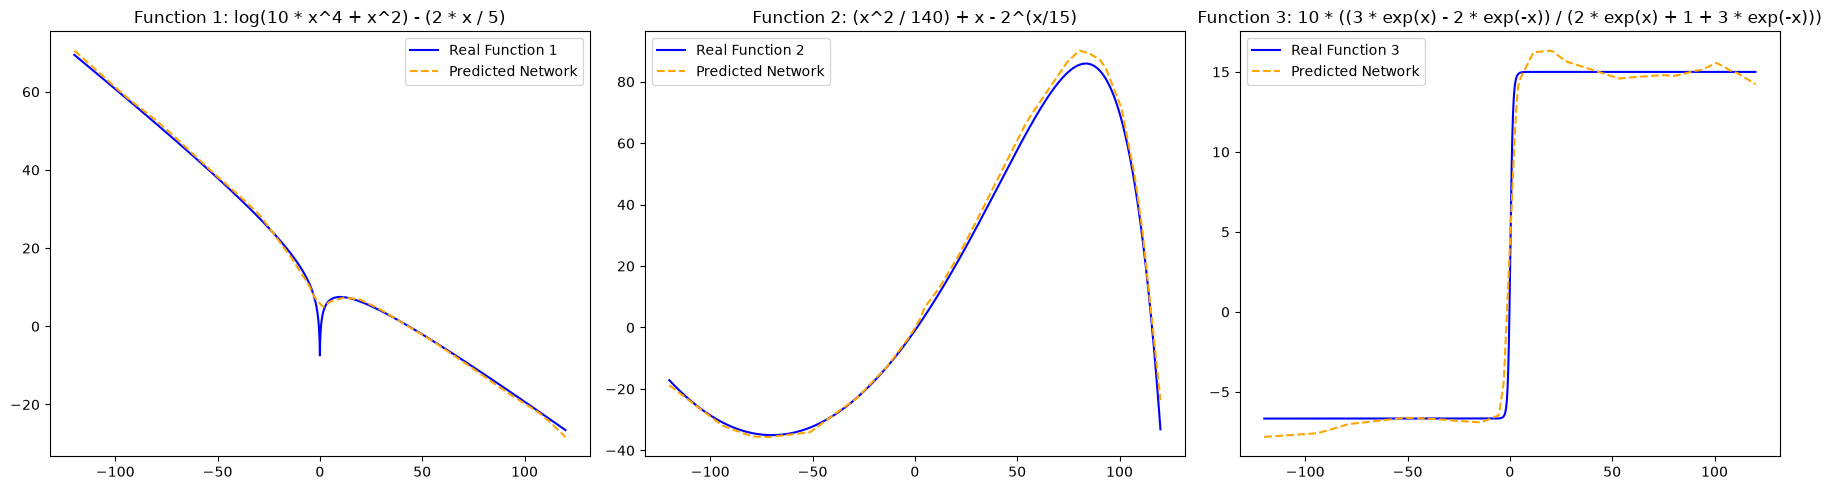

In [20]:
# Defining the loss function for Mean Absolute Error (MAE).
mae_loss_fn = nn.L1Loss()

# Calculating the test loss.
loss_test_total = 0

with torch.no_grad(): # Disabling gradient calculation for testing for efficiency.
    for x_test, y_test in test_loader:
        # Giving the model the test data and obtaining the predictions.
        pred_test = model(x_test)

        # Calculating the test loss.
        loss_test = mae_loss_fn(pred_test, y_test)

        # Accumulating the test loss.
        loss_test_total += loss_test.item()

# Calculating the average test loss.
error_final_mae = loss_test_total / len(test_loader)
print (f'Error final (MAE) on the test set: {error_final_mae:.4f}')

# Visualizing the training and validation loss over epochs.
with torch.no_grad(): # Disabling gradient calculation for visualization for efficiency.
    # Using 'x_input' tensor to get predictions for the entire range of input values.
    total_predictions = model(x_input / 120.0)

# Converting tensors to numpy arrays for visualization (Matplotlib).
x_plot = x.numpy()
y_real = y.numpy()
y_pred = total_predictions.numpy()

# Creating subplots for the three functions.
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plotting the real and predicted values for the first function.
axs[0].plot(x_plot, y_real[:, 0], label='Real Function 1', color='blue')
axs[0].plot(x_plot, y_pred[:, 0], label='Predicted Network', color='orange', linestyle='dashed')
axs[0].set_title('Function 1: log(10 * x^4 + x^2) - (2 * x / 5)')
axs[0].legend()

# Plotting the real and predicted values for the second function.
axs[1].plot(x_plot, y_real[:, 1], label='Real Function 2', color='blue')
axs[1].plot(x_plot, y_pred[:, 1], label='Predicted Network', color='orange', linestyle='dashed')
axs[1].set_title('Function 2: (x^2 / 140) + x - 2^(x/15)')
axs[1].legend()

# Plotting the real and predicted values for the third function.
axs[2].plot(x_plot, y_real[:, 2], label='Real Function 3', color='blue')
axs[2].plot(x_plot, y_pred[:, 2], label='Predicted Network', color='orange', linestyle='dashed')
axs[2].set_title('Function 3: 10 * ((3 * exp(x) - 2 * exp(-x)) / (2 * exp(x) + 1 + 3 * exp(-x)))')
axs[2].legend()

plt.tight_layout()
plt.show()

**Análisis de Resultados**

Tras entrenar el modelo durante 5000 épocas utilizando el optimizador SGD (tasa de aprendizaje de 0.001) y la función de pérdida L1, se ha alcanzado un Error Absoluto Medio (MAE) final en el subconjunto de test de 4.1070.

Considerando que los datos originales fueron perturbados con un ruido gaussiano de desviación típica igual a 5, este valor de error demuestra que el modelo ha logrado generalizar con éxito. La red neuronal no ha memorizado el ruido de los datos de entrenamiento (evitando el sobreajuste u overfitting), sino que ha abstraído la tendencia matemática subyacente de las tres ecuaciones.

Al analizar la visualización de las gráficas, podemos destacar lo siguiente:
1. **Ajuste y Capacidad**: La línea punteada naranja (predicción del modelo) consigue calcar la trayectoria de la línea azul (funciones reales) a lo largo de todo el rango de entrada $x \in [-120, 120]$. La red de tres capas ocultas (128-128-64) tiene suficiente capacidad representacional para abordar las tres salidas de forma simultánea.
2. **Naturaleza de Leaky ReLU**: Si observamos con detalle las curvas más pronunciadas (como el pico máximo de la Función 2), se aprecia que el modelo aproxima los arcos suaves mediante la unión de pequeños segmentos rectos. Esta es la firma visual característica de la función de activación Leaky ReLU, que construye curvas complejas a base de combinaciones lineales por tramos.
3. **Robustez ante el ruido**: El uso de la pérdida L1 (MAE) en lugar de MSE ha sido clave para no castigar en exceso los picos de error inducidos artificialmente por el ruido, logrando que la predicción se mantenga centrada y estable en las zonas más llanas (como los extremos de la Función 3).

En conclusión, la combinación de una correcta normalización de los datos de entrada, la arquitectura profunda con activaciones Leaky ReLU y un entrenamiento prolongado a baja velocidad, ha resultado ser una estrategia óptima para la aproximación simultánea de estas funciones.